In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("hellow world")

hellow world


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AIVerificationAICTE/Dataset/Expanded_AICTE_Approval_Data_5000.csv")

In [ ]:
df.head()

,Institution Name,Location Classification,Program Type,Land Area (Acres),Number of Classrooms,Number of Tutorial Rooms,Number of PG Labs,Number of Workshops,Computer Center Area (sqm),Library Area (sqm),Seminar Hall Area (sqm),Total Student Intake,Approval Status
0,Institution_4947,Rural,UG,12.28,16,4,0,12,204,550,132,546,Approved
1,Institution_6101,Non-Rural,Diploma,0.58,12,3,0,9,257,400,132,322,Not Approved
2,Institution_5459,Non-Rural,Combined,2.57,12,3,30,6,152,450,132,366,Approved
3,Institution_7937,Non-Rural,Combined,3.42,12,3,30,9,263,400,132,203,Approved
4,Institution_3454,Rural,Diploma,3.52,8,2,0,2,190,600,132,127,Not Approved


In [ ]:
df.isnull().sum()

,0
Institution Name,0
Location Classification,0
Program Type,0
Land Area (Acres),0
Number of Classrooms,0
Number of Tutorial Rooms,0
Number of PG Labs,0
Number of Workshops,0
Computer Center Area (sqm),0
Library Area (sqm),0


In [ ]:
df.drop(columns=['Institution Name'],inplace = True)

In [ ]:
df.head()

,Location Classification,Program Type,Land Area (Acres),Number of Classrooms,Number of Tutorial Rooms,Number of PG Labs,Number of Workshops,Computer Center Area (sqm),Library Area (sqm),Seminar Hall Area (sqm),Total Student Intake,Approval Status
0,Rural,UG,12.28,16,4,0,12,204,550,132,546,Approved
1,Non-Rural,Diploma,0.58,12,3,0,9,257,400,132,322,Not Approved
2,Non-Rural,Combined,2.57,12,3,30,6,152,450,132,366,Approved
3,Non-Rural,Combined,3.42,12,3,30,9,263,400,132,203,Approved
4,Rural,Diploma,3.52,8,2,0,2,190,600,132,127,Not Approved


In [ ]:
df['Approval Status'] = df['Approval Status'].map({'Approved': 1, 'Not Approved': 0})


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_encoder = LabelEncoder()
y = le_encoder.fit_transform(df['Approval Status'])

In [ ]:
#encoding the rural label.
df['Location Classification'] = df['Location Classification'].map({'Rural': 0, 'Non-Rural': 1})
df['Location Classification'] = le_encoder.fit_transform(df['Location Classification'])

In [ ]:
#encoding the program type using onehot
one_hot_encoded = pd.get_dummies(df['Program Type'], prefix='Program_Type')

# Convert the boolean columns to integers (True -> 1, False -> 0)
one_hot_encoded = one_hot_encoded.astype(int)

# Concatenate the new one-hot encoded columns with the original DataFrame
df = pd.concat([df, one_hot_encoded], axis=1)

# Remove the original column
df_encoded = df.drop(columns=['Program Type'])


In [ ]:
df_encoded.head()

,Location Classification,Land Area (Acres),Number of Classrooms,Number of Tutorial Rooms,Number of PG Labs,Number of Workshops,Computer Center Area (sqm),Library Area (sqm),Seminar Hall Area (sqm),Total Student Intake,Approval Status,Program_Type_Combined,Program_Type_Diploma,Program_Type_PG,Program_Type_UG
0,0,12.28,16,4,0,12,204,550,132,546,1,0,0,0,1
1,1,0.58,12,3,0,9,257,400,132,322,0,0,1,0,0
2,1,2.57,12,3,30,6,152,450,132,366,1,1,0,0,0
3,1,3.42,12,3,30,9,263,400,132,203,1,1,0,0,0
4,0,3.52,8,2,0,2,190,600,132,127,0,0,1,0,0


In [ ]:
x = df_encoded.drop(columns=['Approval Status'])
print(x.head())

   Location Classification  Land Area (Acres)  Number of Classrooms  \
0                        0              12.28                    16   
1                        1               0.58                    12   
2                        1               2.57                    12   
3                        1               3.42                    12   
4                        0               3.52                     8   

   Number of Tutorial Rooms  Number of PG Labs  Number of Workshops  \
0                         4                  0                   12   
1                         3                  0                    9   
2                         3                 30                    6   
3                         3                 30                    9   
4                         2                  0                    2   

   Computer Center Area (sqm)  Library Area (sqm)  Seminar Hall Area (sqm)  \
0                         204                 550                   

In [ ]:
y = df_encoded['Approval Status']
y[2:20]

,Approval Status
2,1
3,1
4,0
5,1
6,0
7,0
8,1
9,1
10,1
11,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

In [ ]:
x_train.head()

,Location Classification,Land Area (Acres),Number of Classrooms,Number of Tutorial Rooms,Number of PG Labs,Number of Workshops,Computer Center Area (sqm),Library Area (sqm),Seminar Hall Area (sqm),Total Student Intake,Program_Type_Combined,Program_Type_Diploma,Program_Type_PG,Program_Type_UG
337,1,0.88,4,1,0,2,154,550,132,245,0,1,0,0
2127,1,2.23,20,5,50,10,208,550,132,493,0,0,1,0
2592,1,1.81,8,2,20,6,263,550,132,437,0,0,1,0
918,0,13.03,8,2,20,4,258,450,132,326,0,0,1,0
4418,1,4.92,8,2,20,6,222,600,132,496,1,0,0,0


In [ ]:
y_train[350:390]

,Approval Status
1458,0
3383,1
3526,0
3478,0
1805,1
2784,0
1148,0
3871,0
3485,1
125,0


In [ ]:
len(x_train)

4000

In [ ]:
#applying scaling on our columns before training
from sklearn.preprocessing import StandardScaler

# Select numerical columns
numerical_cols = ['Land Area (Acres)', 'Number of Classrooms', 'Number of Tutorial Rooms',
                  'Number of PG Labs', 'Number of Workshops', 'Computer Center Area (sqm)',
                  'Library Area (sqm)', 'Seminar Hall Area (sqm)', 'Total Student Intake']

# Initialize the scaler
scaler = StandardScaler()



In [ ]:
# Apply scaling on training set train
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])

In [ ]:
# Apply scaling on training set test
x_test[numerical_cols] = scaler.fit_transform(x_test[numerical_cols])


In [ ]:
x_train.head()

,Location Classification,Land Area (Acres),Number of Classrooms,Number of Tutorial Rooms,Number of PG Labs,Number of Workshops,Computer Center Area (sqm),Library Area (sqm),Seminar Hall Area (sqm),Total Student Intake,Program_Type_Combined,Program_Type_Diploma,Program_Type_PG,Program_Type_UG
382,0,9.43,20,5,0,15,74,600,132,425,0,0,0,1
538,1,1.89,4,1,0,2,112,600,132,380,0,0,0,1
1493,0,6.50,4,1,0,4,97,600,132,360,0,0,0,1
1112,0,10.47,16,4,40,12,132,400,132,210,0,0,1,0
324,0,10.00,16,4,0,4,99,600,132,454,0,1,0,0


In [ ]:
#dropping column: seminal hall area , since its static 0
x_train = x_train.drop(columns=['Seminar Hall Area (sqm)'])
x_test = x_test.drop(columns=['Seminar Hall Area (sqm)'])

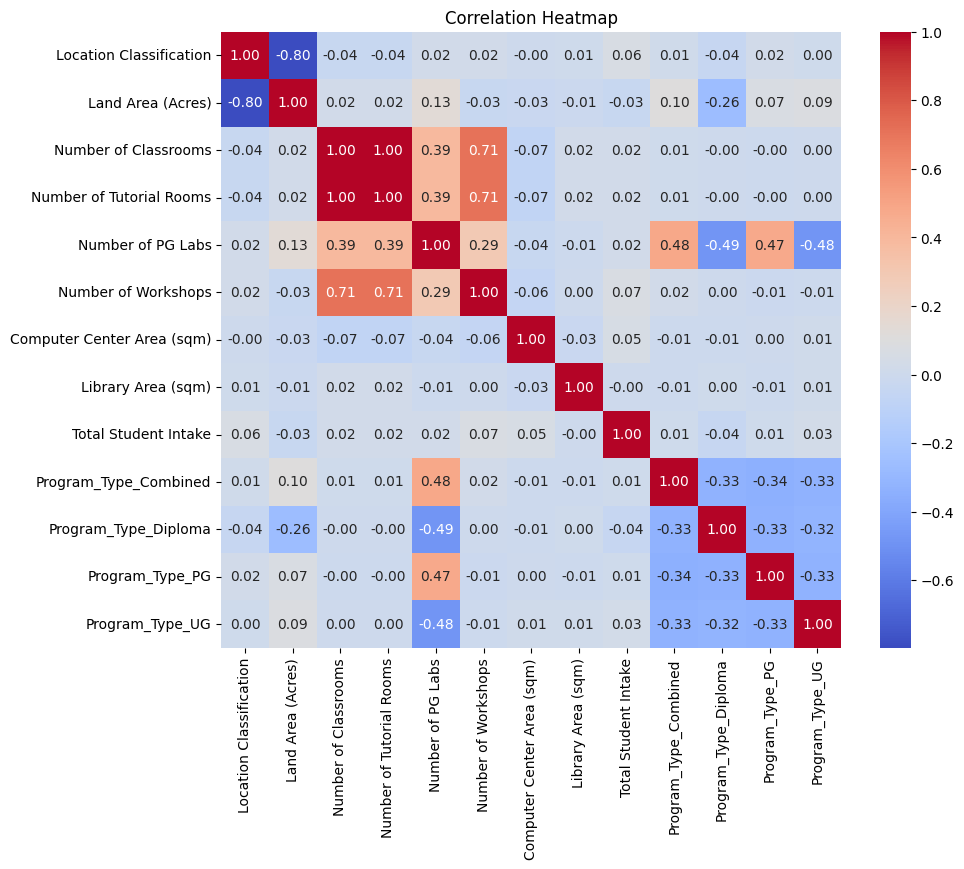

In [ ]:
corr = x_train.corr()
#visualization of data
# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

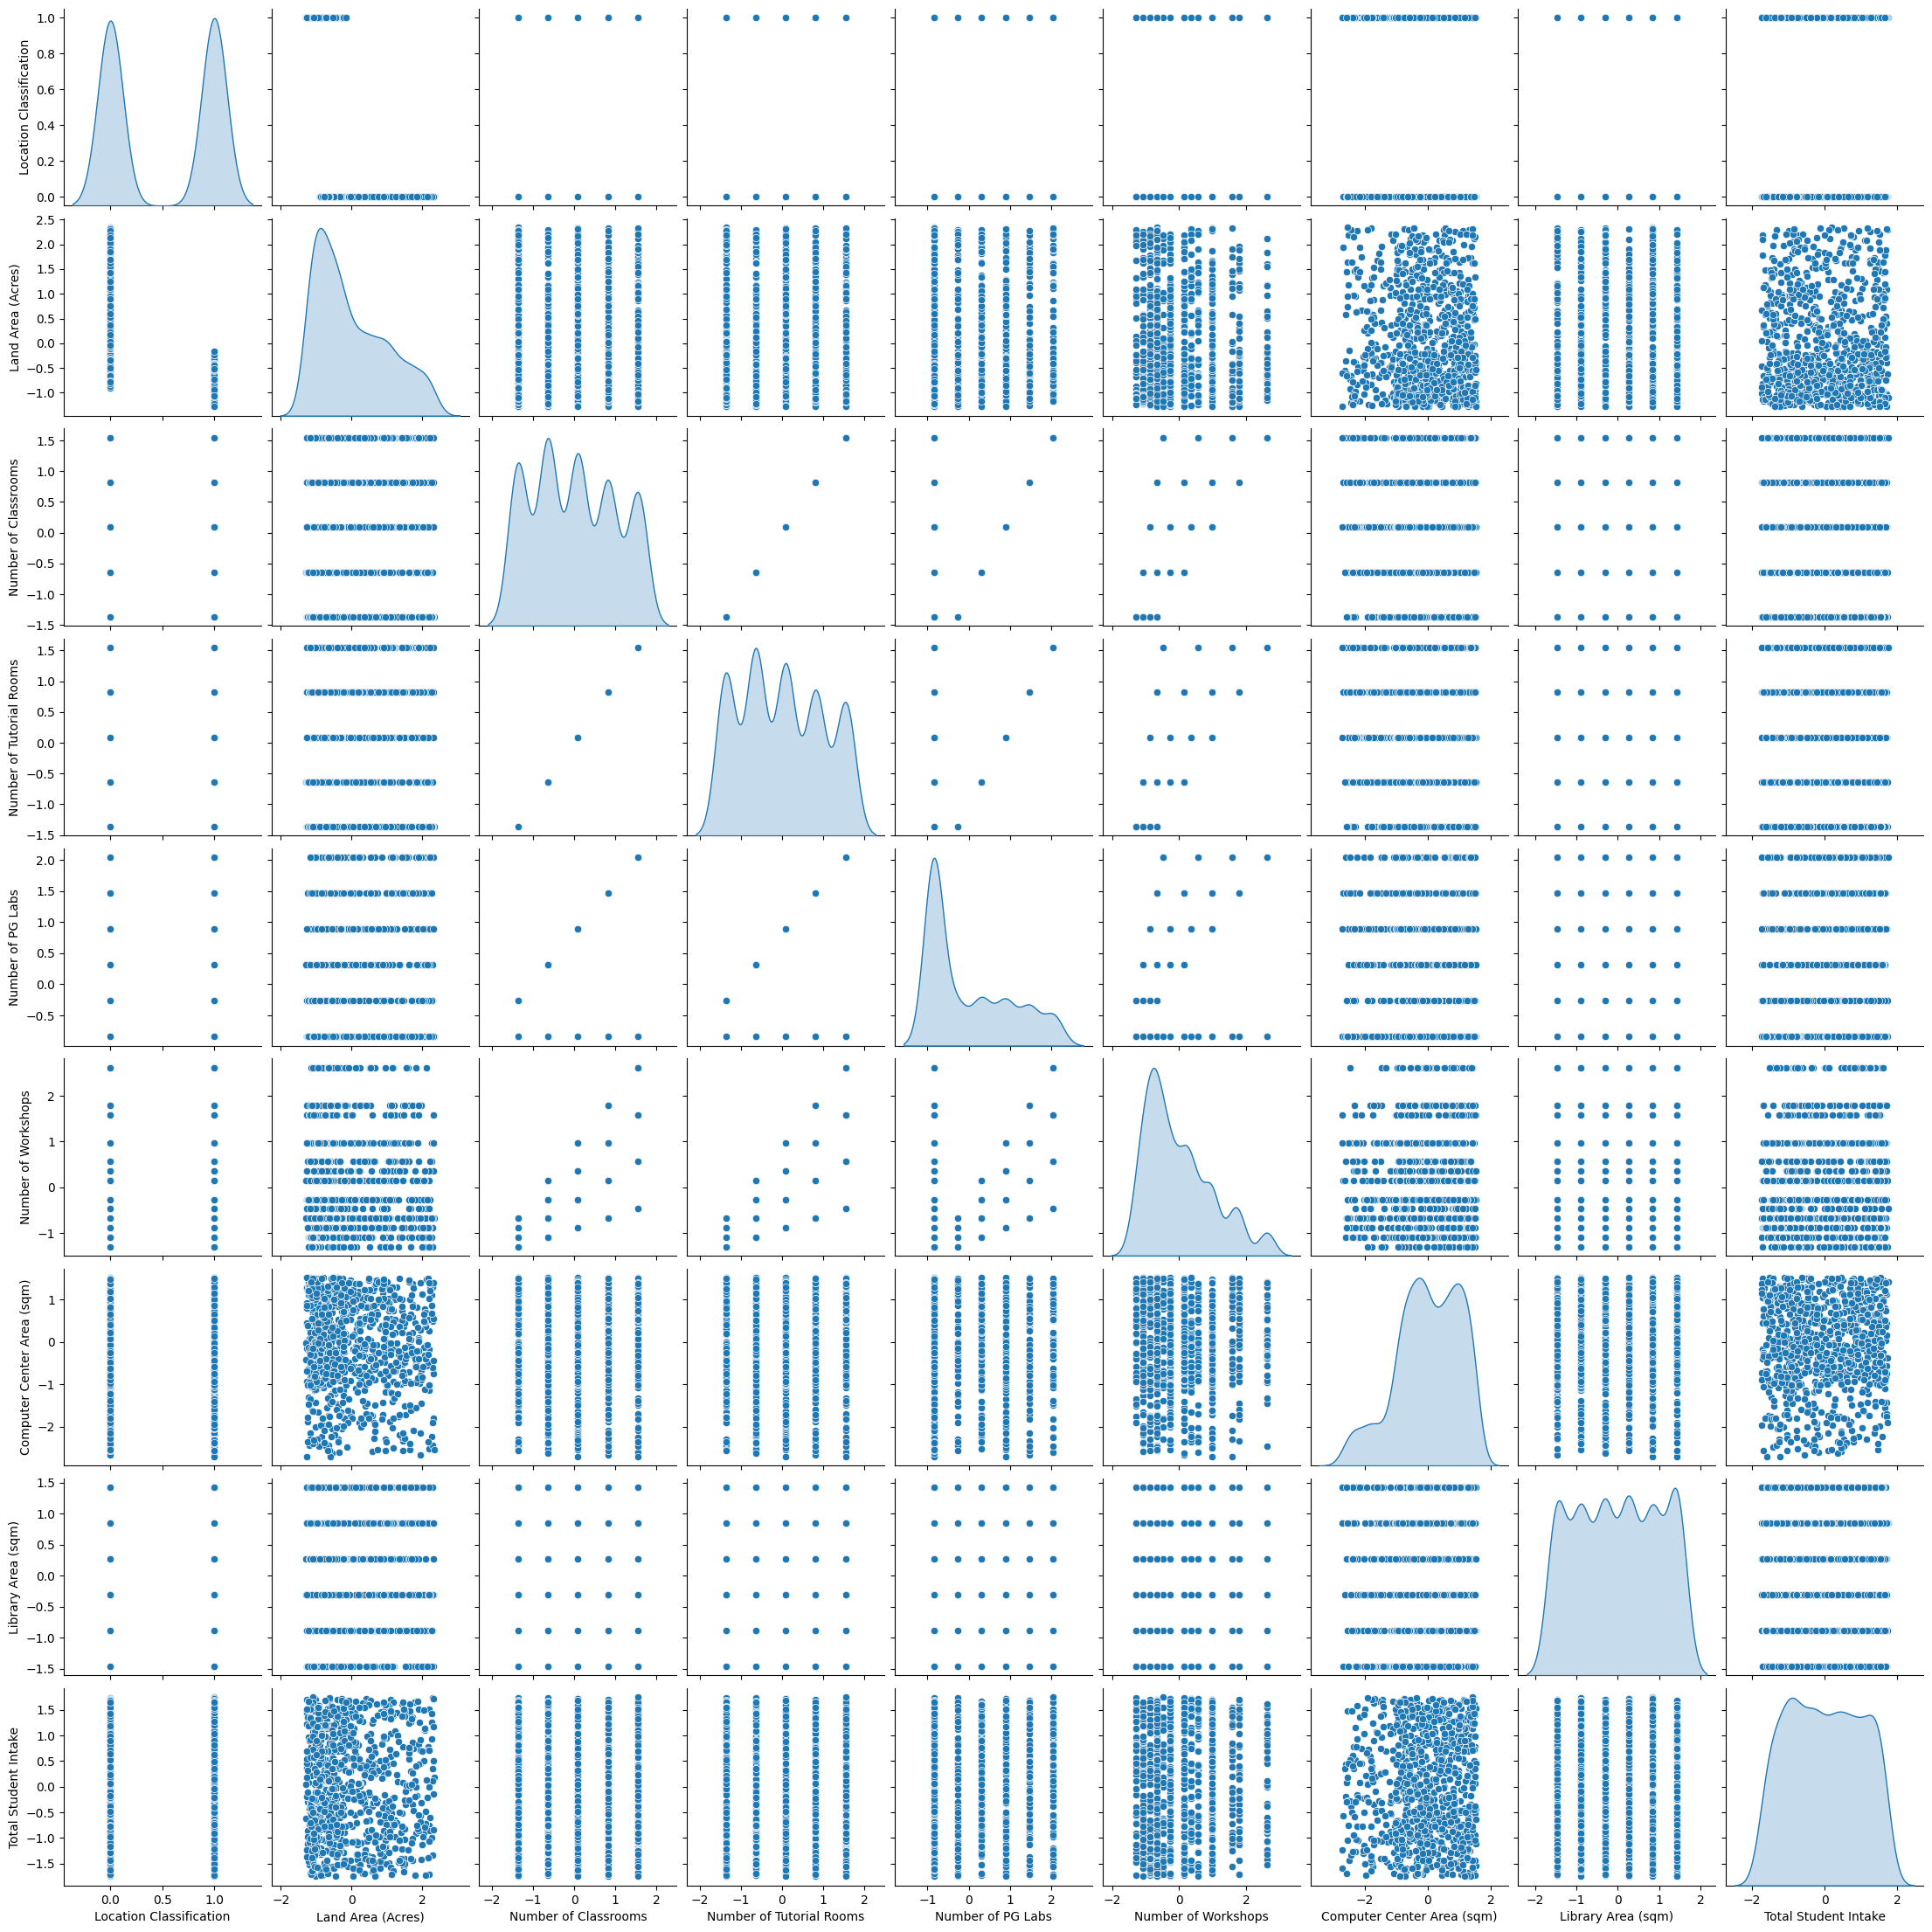

In [ ]:
sns.pairplot(x_train.drop(columns=['Program_Type_Combined', 'Program_Type_Diploma', 'Program_Type_UG', 'Program_Type_PG']), diag_kind='kde')
plt.show()

In [ ]:
#training our model initially
from sklearn.tree import DecisionTreeRegressor

# Initialize the model
model = DecisionTreeRegressor(random_state=42)

# Train the model
model.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
pred_1 = model.predict(x_test)

In [ ]:
print(pred_1)

[1. 1. 1. 0. 0.]


In [ ]:
print(y_test.head())

1116    0
1368    0
422     0
413     0
451     0
Name: Approval Status, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy*100}')

Accuracy: 100.0


In [ ]:
print(y_pred[350:370])
print(y_test[350:370])

[]
Series([], Name: Approval Status, dtype: int64)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    'max_depth': [3, 5, 7, 10, None],  # Varying tree depth
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split
    'min_samples_leaf': [1, 2, 4],    # Minimum samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2'],  # Features to consider at each split
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],  # Valid criteria for DecisionTreeRegressor
}


# Initialize the model
model = DecisionTreeRegressor(random_state=42)

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(x_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Use the best estimator from the grid search
best_model = grid_search.best_estimator_

# Train the model on the full training set
best_model.fit(x_train, y_train)

# Evaluate the model
y_pred = best_model.predict(x_test)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best Hyperparameters: {'criterion': 'absolute_error', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}


In [ ]:
#accuracy after updation :
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy*100}')

Accuracy: 97.66666666666667


In [ ]:
#trying random forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],  # Removed 'auto'
}

# Grid search for Random Forest
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)
grid_search_rf.fit(x_train, y_train)

# Best parameters from grid search
print("Best parameters found: ", grid_search_rf.best_params_)

# Evaluate the best model
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(x_test)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
292 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Best parameters found:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
!pip install xgboost


In [ ]:
unique_values = y_test.unique()
print(unique_values)

[0 1]


In [ ]:
#trying xgboost initially.
import xgboost as xgb
from sklearn.metrics import accuracy_score


# Initialize the XGBoost classifier with tuned hyperparameters
xgb_model = xgb.XGBClassifier(
    max_depth=10,                # Depth of each tree (default 6)
    learning_rate=0.1,          # Step size shrinkage (default 0.3)
    n_estimators=200,           # Number of boosting rounds (default 100)
    subsample=0.8,              # Fraction of samples for each boosting round
    colsample_bytree=0.8,       # Fraction of features for each boosting round
    gamma=0.1,                  # Minimum loss reduction to make a split
    reg_lambda=1.0,             # L2 regularization term
    reg_alpha=0.0,              # L1 regularization term
    objective='binary:logistic',# Binary classification task
    eval_metric='logloss',      # Loss function for binary classification
)

# Train the model
xgb_model.fit(x_train, y_train)




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Make predictions on the validation set
y_pred_xg = xgb_model.predict(x_test)
print(y_test[1:10])
print (y_pred_xg[1:10])

1495    0
1282    1
469     1
477     1
501     1
204     1
297     0
1234    0
546     1
Name: Approval Status, dtype: int64
[0 1 1 1 1 1 0 0 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred_xg)
print(f'Accuracy: {accuracy*100}')

Accuracy: 100.0


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
# Initialize the SVM classifier with tuned hyperparameters
svm_model = SVC(
    kernel='rbf',        # Radial Basis Function (RBF) kernel (you can change to 'linear', 'poly', or 'sigmoid')
    C=1.0,               # Regularization parameter
    gamma='scale'        # Kernel coefficient for 'rbf', 'poly', and 'sigmoid' (auto-adjusted with 'scale')
)

# Train the model
svm_model.fit(x_train, y_train)
# Predict on the test set
y_pred_svm = svm_model.predict(x_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 72.20%


In [ ]:
#trying mean scaling and testing again:
'''from sklearn.preprocessing import MinMaxScaler

# Custom function for mean scaling
def mean_scaling(X):
    return (X - np.mean(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0))

# Apply mean scaling to the data
X_train_scaled = mean_scaling(x_train)
X_test_scaled = mean_scaling(x_test)
#dropping column: seminal hall area , since its static 0
X_train_scaled = X_train_scaled.drop(columns=['Seminar Hall Area (sqm)'])
X_test_scaled = X_test_scaled.drop(columns=['Seminar Hall Area (sqm)'])
'''

In [ ]:
#trying min-max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0.1, 0.9))
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)
#dropping column: seminal hall area , since its static 0
#X_train_scaled = X_train_scaled.drop(columns=['Seminar Hall Area (sqm)'])
#X_test_scaled = X_test_scaled.drop(columns=['Seminar Hall Area (sqm)'])

In [ ]:
X_train_scaled[:5]


array([[0.9       , 0.12044199, 0.1       , 0.1       , 0.1       ,
        0.14210526, 0.4328    , 0.58      , 0.332     , 0.1       ,
        0.9       , 0.1       , 0.1       ],
       [0.9       , 0.19502762, 0.9       , 0.9       , 0.9       ,
        0.47894737, 0.6056    , 0.58      , 0.7288    , 0.1       ,
        0.1       , 0.9       , 0.1       ],
       [0.9       , 0.1718232 , 0.3       , 0.3       , 0.42      ,
        0.31052632, 0.7816    , 0.58      , 0.6392    , 0.1       ,
        0.1       , 0.9       , 0.1       ],
       [0.1       , 0.79171271, 0.3       , 0.3       , 0.42      ,
        0.22631579, 0.7656    , 0.26      , 0.4616    , 0.1       ,
        0.1       , 0.9       , 0.1       ],
       [0.9       , 0.34364641, 0.3       , 0.3       , 0.42      ,
        0.31052632, 0.6504    , 0.74      , 0.7336    , 0.9       ,
        0.1       , 0.1       , 0.1       ]])

In [ ]:
# Initialize the SVM classifier with tuned hyperparameters
svm_model = SVC(
    kernel='rbf',        # Radial Basis Function (RBF) kernel (you can change to 'linear', 'poly', or 'sigmoid')
    C=1.0,               # Regularization parameter
    gamma='scale'        # Kernel coefficient for 'rbf', 'poly', and 'sigmoid' (auto-adjusted with 'scale')
)

# Train the model
svm_model.fit(X_train_scaled, y_train)
# Predict on the test set
y_pred_svm = svm_model.predict(X_test_scaled)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
# mean based scaling gets this score with svm's

Validation Accuracy: 92.30%


In [ ]:
#trying random forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],  # Removed 'auto'
}

# Grid search for Random Forest
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train_scaled, y_train)

# Best parameters from grid search
print("Best parameters found: ", grid_search_rf.best_params_)

# Evaluate the best model
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_scaled)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
acc = accuracy_score(y_test,y_pred_rf);

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
X_train_scaled.head()

,Location Classification,Land Area (Acres),Number of Classrooms,Number of Tutorial Rooms,Number of PG Labs,Number of Workshops,Computer Center Area (sqm),Library Area (sqm),Total Student Intake,Program_Type_Combined,Program_Type_Diploma,Program_Type_PG,Program_Type_UG
478,0.483333,-0.346863,-0.227083,-0.227083,-0.300667,-0.076623,0.088523,-0.100667,0.419655,-0.2575,0.754167,-0.251667,-0.245
96,-0.516667,-0.002250,0.022917,0.022917,0.299333,0.239167,0.256523,-0.500667,0.165655,0.7425,-0.245833,-0.251667,-0.245
199,0.483333,-0.097554,-0.227083,-0.227083,-0.300667,-0.076623,0.208523,-0.300667,0.203655,-0.2575,-0.245833,-0.251667,0.755
560,0.483333,-0.277803,0.022917,0.022917,-0.300667,-0.234518,-0.267477,0.099333,-0.204345,-0.2575,0.754167,-0.251667,-0.245
341,-0.516667,0.323717,0.022917,0.022917,0.299333,0.239167,0.124523,0.099333,-0.216345,0.7425,-0.245833,-0.251667,-0.245


In [ ]:
#trying xgboost initially.
import xgboost as xgb
from sklearn.metrics import accuracy_score


# Initialize the XGBoost classifier with tuned hyperparameters
xgb_model = xgb.XGBClassifier(
    max_depth=10,                # Depth of each tree (default 6)
    learning_rate=0.1,          # Step size shrinkage (default 0.3)
    n_estimators=100,           # Number of boosting rounds (default 100)
    subsample=0.8,              # Fraction of samples for each boosting round
    colsample_bytree=0.8,       # Fraction of features for each boosting round
    gamma=0.1,                  # Minimum loss reduction to make a split
    reg_lambda=1.0,             # L2 regularization term
    reg_alpha=0.0,              # L1 regularization term
    objective='binary:logistic',# Binary classification task
    eval_metric='logloss',      # Loss function for binary classification
)

# Train the model
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test , xgb_pred)
print(f'Accuracy: {accuracy*100}')
#achieved 100% certain accuracy using xgb booost

Accuracy: 100.0


In [ ]:
from sklearn.metrics import mean_squared_error

# Predict on the test set
#y_pred = model.predict(x_test)

# Calculate the MSE and R-squared score
mse = mean_squared_error(y_test, xgb_pred)


print(f'Mean Squared Error: {mse}')


Mean Squared Error: 0.0
